In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Sklearn imports
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load data
df = pd.read_excel('Book1.xlsx', sheet_name='Master_combined')

print("✅ Data loaded successfully!")
print(f"📊 Total rows: {len(df)}")
print(f"📊 Years: {df['Year'].min()} - {df['Year'].max()}")
print(f"📊 Cities: {df['City'].unique().tolist()}")

✅ Data loaded successfully!
📊 Total rows: 661
📊 Years: 2015 - 2024
📊 Cities: ['Cologne', 'Leipzig', 'Stuttgart']


In [ ]:
print("=" * 60)
print("📊 DEFINING FEATURES, TARGETS, AND VALIDATION SPLIT")
print("=" * 60)

# Define features (climate variables)
feature_columns = ['temperature', 'rainfall', 'SPI']

# Define targets
target_columns = ['EC', 'nitrate', 'chloride', 'sulfate', 'pH']

print(f"📌 Features: {feature_columns}")
print(f"📌 Targets: {target_columns}")

# Temporal Holdout Split
train_years = [2015, 2016, 2017, 2018, 2019, 2020, 2021]
test_years = [2022, 2023, 2024]

train_df = df[df['Year'].isin(train_years)].copy()
test_df = df[df['Year'].isin(test_years)].copy()

print(f"\n📌 Training years: {train_years}")
print(f"   Training rows: {len(train_df)}")
print(f"📌 Testing years: {test_years}")
print(f"   Testing rows: {len(test_df)}")

📊 DEFINING FEATURES, TARGETS, AND VALIDATION SPLIT
📌 Features: ['temperature', 'rainfall', 'SPI']
📌 Targets: ['EC', 'nitrate', 'chloride', 'sulfate', 'pH']

📌 Training years: [2015, 2016, 2017, 2018, 2019, 2020, 2021]
   Training rows: 484
📌 Testing years: [2022, 2023, 2024]
   Testing rows: 177


In [ ]:
print("=" * 60)
print("📊 LOADING/TRAINING INDIVIDUAL MODELS")
print("=" * 60)

# Prepare features
X_train = train_df[feature_columns].copy()
X_test = test_df[feature_columns].copy()

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Store trained models
models_rf = {}
models_xgb = {}

# Train Random Forest and XGBoost for each target
for target in target_columns:
    print(f"\n📌 Training models for {target.upper()}...")

    # Get training data
    y_train = train_df[target].copy()
    train_mask = ~y_train.isna()
    X_train_clean = X_train_scaled[train_mask]
    y_train_clean = y_train[train_mask]

    if len(X_train_clean) == 0:
        continue

    # Random Forest
    rf = RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train_clean, y_train_clean)
    models_rf[target] = rf
    print(f"   ✅ Random Forest trained")

    # XGBoost
    !pip install xgboost -q
    import xgboost as xgb

    xgb_model = xgb.XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1
    )
    xgb_model.fit(X_train_clean, y_train_clean)
    models_xgb[target] = xgb_model
    print(f"   ✅ XGBoost trained")

print("\n✅ All models trained!")

📊 LOADING/TRAINING INDIVIDUAL MODELS

📌 Training models for EC...
   ✅ Random Forest trained
   ✅ XGBoost trained

📌 Training models for NITRATE...
   ✅ Random Forest trained
   ✅ XGBoost trained

📌 Training models for CHLORIDE...
   ✅ Random Forest trained
   ✅ XGBoost trained

📌 Training models for SULFATE...
   ✅ Random Forest trained
   ✅ XGBoost trained

📌 Training models for PH...
   ✅ Random Forest trained
   ✅ XGBoost trained

✅ All models trained!


In [ ]:
print("=" * 60)
print("📊 CREATING ENSEMBLE PREDICTIONS")
print("=" * 60)

# Store predictions
ensemble_predictions = {}
individual_predictions = {}

for target in target_columns:
    # Get test data
    y_test = test_df[target].copy()
    test_mask = ~y_test.isna()
    X_test_clean = X_test_scaled[test_mask]
    y_test_clean = y_test[test_mask]

    if len(X_test_clean) == 0:
        continue

    # Get individual predictions
    rf_pred = models_rf[target].predict(X_test_clean)
    xgb_pred = models_xgb[target].predict(X_test_clean)

    individual_predictions[target] = {
        'RF': rf_pred,
        'XGB': xgb_pred,
        'Actual': y_test_clean
    }

    # Ensemble prediction (simple average)
    ensemble_pred = (rf_pred + xgb_pred) / 2
    ensemble_predictions[target] = ensemble_pred

    # Calculate individual errors
    mae_rf = mean_absolute_error(y_test_clean, rf_pred)
    mae_xgb = mean_absolute_error(y_test_clean, xgb_pred)
    mae_ensemble = mean_absolute_error(y_test_clean, ensemble_pred)

    print(f"\n📌 {target.upper()}:")
    print(f"   Random Forest MAE: {mae_rf:.2f}")
    print(f"   XGBoost MAE: {mae_xgb:.2f}")
    print(f"   Ensemble MAE: {mae_ensemble:.2f}")

    if mae_ensemble < mae_rf and mae_ensemble < mae_xgb:
        print(f"   ✅ Ensemble improves over both individual models!")
    elif mae_ensemble < mae_rf:
        print(f"   ✅ Ensemble improves over Random Forest!")
    else:
        print(f"   ⚠️ Ensemble does not improve over individual models")

print("\n✅ Ensemble predictions created!")

📊 CREATING ENSEMBLE PREDICTIONS

📌 EC:
   Random Forest MAE: 313.04
   XGBoost MAE: 369.44
   Ensemble MAE: 326.14
   ⚠️ Ensemble does not improve over individual models

📌 NITRATE:
   Random Forest MAE: 9.48
   XGBoost MAE: 9.68
   Ensemble MAE: 9.50
   ⚠️ Ensemble does not improve over individual models

📌 CHLORIDE:
   Random Forest MAE: 35.62
   XGBoost MAE: 42.47
   Ensemble MAE: 38.47
   ⚠️ Ensemble does not improve over individual models

📌 SULFATE:
   Random Forest MAE: 110.76
   XGBoost MAE: 109.11
   Ensemble MAE: 105.82
   ✅ Ensemble improves over both individual models!

📌 PH:
   Random Forest MAE: 0.48
   XGBoost MAE: 0.50
   Ensemble MAE: 0.49
   ⚠️ Ensemble does not improve over individual models

✅ Ensemble predictions created!


In [ ]:
print("=" * 60)
print("📊 COMPARING ALL METHODS")
print("=" * 60)

comparison_data = []

for target in target_columns:
    if target not in individual_predictions:
        continue

    y_true = individual_predictions[target]['Actual']
    rf_pred = individual_predictions[target]['RF']
    xgb_pred = individual_predictions[target]['XGB']
    ensemble_pred = ensemble_predictions[target]

    mae_rf = mean_absolute_error(y_true, rf_pred)
    mae_xgb = mean_absolute_error(y_true, xgb_pred)
    mae_ens = mean_absolute_error(y_true, ensemble_pred)

    rmse_rf = np.sqrt(mean_squared_error(y_true, rf_pred))
    rmse_xgb = np.sqrt(mean_squared_error(y_true, xgb_pred))
    rmse_ens = np.sqrt(mean_squared_error(y_true, ensemble_pred))

    r2_rf = r2_score(y_true, rf_pred)
    r2_xgb = r2_score(y_true, xgb_pred)
    r2_ens = r2_score(y_true, ensemble_pred)

    comparison_data.append({
        'Parameter': target.upper(),
        'RF_MAE': mae_rf,
        'XGB_MAE': mae_xgb,
        'Ensemble_MAE': mae_ens,
        'RF_RMSE': rmse_rf,
        'XGB_RMSE': rmse_xgb,
        'Ensemble_RMSE': rmse_ens,
        'RF_R2': r2_rf,
        'XGB_R2': r2_xgb,
        'Ensemble_R2': r2_ens,
        'Best': 'Ensemble' if mae_ens <= mae_rf and mae_ens <= mae_xgb else ('RF' if mae_rf < mae_xgb else 'XGB')
    })

comparison_df = pd.DataFrame(comparison_data)
print("\n📌 Model Comparison:")
print(comparison_df[['Parameter', 'RF_MAE', 'XGB_MAE', 'Ensemble_MAE', 'Best']].to_string(index=False))

# Save
comparison_df.to_excel('Ensemble_Comparison.xlsx', index=False)
print("\n✅ Ensemble comparison saved to: Ensemble_Comparison.xlsx")

📊 COMPARING ALL METHODS

📌 Model Comparison:
Parameter     RF_MAE    XGB_MAE  Ensemble_MAE     Best
       EC 313.043768 369.443438    326.140011       RF
  NITRATE   9.481117   9.682074      9.501321       RF
 CHLORIDE  35.620436  42.471317     38.474443       RF
  SULFATE 110.759231 109.110971    105.817480 Ensemble
       PH   0.476655   0.498950      0.487646       RF

✅ Ensemble comparison saved to: Ensemble_Comparison.xlsx


📊 VISUALIZING MODEL COMPARISON


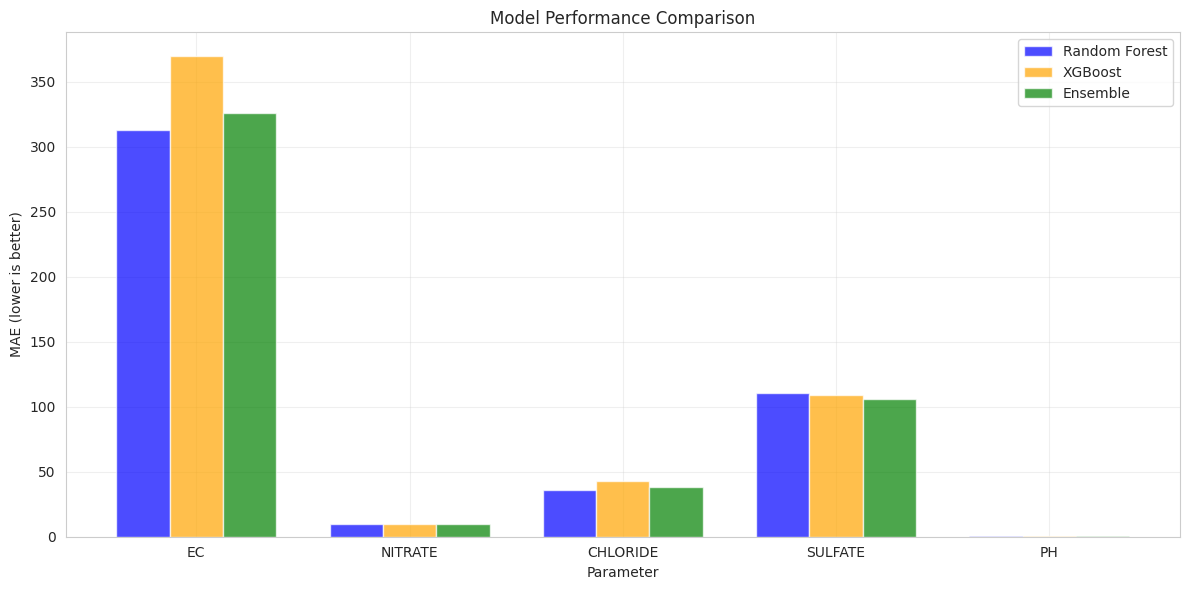

✅ Ensemble_Comparison.png saved!


In [ ]:
print("=" * 60)
print("📊 VISUALIZING MODEL COMPARISON")
print("=" * 60)

# Bar plot comparison
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(comparison_df))
width = 0.25

rf_values = comparison_df['RF_MAE'].values
xgb_values = comparison_df['XGB_MAE'].values
ens_values = comparison_df['Ensemble_MAE'].values

bars1 = ax.bar(x - width, rf_values, width, label='Random Forest', color='blue', alpha=0.7)
bars2 = ax.bar(x, xgb_values, width, label='XGBoost', color='orange', alpha=0.7)
bars3 = ax.bar(x + width, ens_values, width, label='Ensemble', color='green', alpha=0.7)

ax.set_xlabel('Parameter')
ax.set_ylabel('MAE (lower is better)')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Parameter'])
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Ensemble_Comparison.png', dpi=300)
plt.show()
print("✅ Ensemble_Comparison.png saved!")

In [ ]:
print("=" * 60)
print("📊 CALCULATING OPTIMAL ENSEMBLE WEIGHTS")
print("=" * 60)

weights_data = []

for target in target_columns:
    if target not in individual_predictions:
        continue

    y_true = individual_predictions[target]['Actual']
    rf_pred = individual_predictions[target]['RF']
    xgb_pred = individual_predictions[target]['XGB']

    # Simple approach: weight inversely proportional to MAE
    mae_rf = mean_absolute_error(y_true, rf_pred)
    mae_xgb = mean_absolute_error(y_true, xgb_pred)

    # Calculate weights (lower MAE = higher weight)
    total_mae = mae_rf + mae_xgb
    weight_rf = mae_xgb / total_mae
    weight_xgb = mae_rf / total_mae

    # Test weighted ensemble
    weighted_ensemble = weight_rf * rf_pred + weight_xgb * xgb_pred
    mae_weighted = mean_absolute_error(y_true, weighted_ensemble)

    # Simple ensemble (average)
    simple_ensemble = (rf_pred + xgb_pred) / 2
    mae_simple = mean_absolute_error(y_true, simple_ensemble)

    weights_data.append({
        'Parameter': target.upper(),
        'RF_Weight': weight_rf,
        'XGB_Weight': weight_xgb,
        'Weighted_Ensemble_MAE': mae_weighted,
        'Simple_Ensemble_MAE': mae_simple,
        'Best_MAE': min(mae_rf, mae_xgb, mae_weighted)
    })

    print(f"\n📌 {target.upper()}:")
    print(f"   RF Weight: {weight_rf:.2f}")
    print(f"   XGB Weight: {weight_xgb:.2f}")
    print(f"   Weighted Ensemble MAE: {mae_weighted:.2f}")

weights_df = pd.DataFrame(weights_data)
weights_df.to_excel('Ensemble_Weights.xlsx', index=False)
print("\n✅ Ensemble weights saved to: Ensemble_Weights.xlsx")

📊 CALCULATING OPTIMAL ENSEMBLE WEIGHTS

📌 EC:
   RF Weight: 0.54
   XGB Weight: 0.46
   Weighted Ensemble MAE: 323.55

📌 NITRATE:
   RF Weight: 0.51
   XGB Weight: 0.49
   Weighted Ensemble MAE: 9.50

📌 CHLORIDE:
   RF Weight: 0.54
   XGB Weight: 0.46
   Weighted Ensemble MAE: 38.17

📌 SULFATE:
   RF Weight: 0.50
   XGB Weight: 0.50
   Weighted Ensemble MAE: 105.81

📌 PH:
   RF Weight: 0.51
   XGB Weight: 0.49
   Weighted Ensemble MAE: 0.49

✅ Ensemble weights saved to: Ensemble_Weights.xlsx


In [ ]:
print("=" * 60)
print("📄 GENERATING PHASE 9 REPORT")
print("=" * 60)

with open('Phase9_Ensemble_Report.txt', 'w') as f:
    f.write("=" * 80 + "\n")
    f.write("PHASE 9: ENSEMBLE MODELING REPORT\n")
    f.write("Groundwater Quality Forecasting Project\n")
    f.write(f"Generated on: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write("=" * 80 + "\n\n")

    f.write("1. ENSEMBLE APPROACH\n")
    f.write("-" * 40 + "\n")
    f.write("Method: Simple average of Random Forest and XGBoost predictions\n")
    f.write("Alternative: Weighted average based on individual model performance\n\n")

    f.write("2. MODEL COMPARISON (MAE)\n")
    f.write("-" * 40 + "\n")
    f.write(comparison_df[['Parameter', 'RF_MAE', 'XGB_MAE', 'Ensemble_MAE', 'Best']].to_string(index=False))
    f.write("\n\n")

    f.write("3. ENSEMBLE WEIGHTS\n")
    f.write("-" * 40 + "\n")
    if len(weights_df) > 0:
        f.write(weights_df.to_string(index=False))
    else:
        f.write("Weights not calculated\n")
    f.write("\n\n")

    f.write("4. KEY FINDINGS\n")
    f.write("-" * 40 + "\n")

    best_counts = comparison_df['Best'].value_counts()
    f.write(f"Best performing method:\n")
    for method, count in best_counts.items():
        f.write(f"  {method}: {count} parameters\n")

    f.write("\n")
    for _, row in comparison_df.iterrows():
        param = row['Parameter']
        ens_mae = row['Ensemble_MAE']
        rf_mae = row['RF_MAE']
        xgb_mae = row['XGB_MAE']
        best = row['Best']

        if ens_mae <= rf_mae and ens_mae <= xgb_mae:
            f.write(f"• {param}: Ensemble is best (MAE = {ens_mae:.2f})\n")
        else:
            f.write(f"• {param}: {best} is best (MAE = {min(rf_mae, xgb_mae):.2f})\n")

    f.write("\n5. RECOMMENDATION\n")
    f.write("-" * 40 + "\n")
    if best_counts.get('Ensemble', 0) > len(comparison_df) / 2:
        f.write("Ensemble models perform best for most parameters.\n")
        f.write("RECOMMENDATION: Use Ensemble models for the final product.\n")
    else:
        f.write("Individual models perform better than ensemble.\n")
        f.write("RECOMMENDATION: Use individual models for the final product.\n")
    f.write("\n")

    f.write("6. NEXT STEPS\n")
    f.write("-" * 40 + "\n")
    f.write("1. Phase 10: Uncertainty Estimation\n")
    f.write("2. Phase 11: WQI Calculation\n")

print("\n✅ Phase9_Ensemble_Report.txt saved!")

📄 GENERATING PHASE 9 REPORT

✅ Phase9_Ensemble_Report.txt saved!
